In [51]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
## Load Dataset

In [53]:

df = pd.read_csv("supply_chain_data.csv")

In [54]:
## Cek Data Head

In [55]:
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [56]:
## Cek tipe data setiap kolum
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    object 
 1   SKU                      100 non-null    object 
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 non-null    int64  
 5   Revenue generated        100 non-null    float64
 6   Customer demographics    100 non-null    object 
 7   Stock levels             100 non-null    int64  
 8   Lead times               100 non-null    int64  
 9   Order quantities         100 non-null    int64  
 10  Shipping times           100 non-null    int64  
 11  Shipping carriers        100 non-null    object 
 12  Shipping costs           100 non-null    float64
 13  Supplier name            100 non-null    object 
 14  Location                 10

In [57]:
## Cek Data yang kosong
df.isnull().sum()

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


In [58]:
## Cek Data Duplicated
df.duplicated().sum()

np.int64(0)

In [59]:
df.describe()

,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [60]:
# Cek Outlier
num_cols = df.select_dtypes(include='number').columns
def iqr_bounds(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower, upper

print("DETEKSI OUTLIER PER KOLOM NUMERIK")
print("=" * 65)
outlier_report = {}

for col in num_cols:
    Q1, Q3, IQR, lower, upper = iqr_bounds(df[col])
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_report[col] = {'Q1':Q1,'Q3':Q3,'IQR':IQR,'Lower':lower,'Upper':upper,'N_Outlier':n_out}
    print(f"  [{col}]  Q1={Q1:.1f}  Q3={Q3:.1f}  IQR={IQR:.1f}  "
          f"Bounds=[{lower:.1f}, {upper:.1f}]  Outlier={n_out} ({pct:.1f}%)")

DETEKSI OUTLIER PER KOLOM NUMERIK
  [Price]  Q1=19.6  Q3=77.2  IQR=57.6  Bounds=[-66.8, 163.6]  Outlier=0 (0.0%)
  [Availability]  Q1=22.8  Q3=75.0  IQR=52.2  Bounds=[-55.6, 153.4]  Outlier=0 (0.0%)
  [Number of products sold]  Q1=184.2  Q3=704.2  IQR=520.0  Bounds=[-595.8, 1484.2]  Outlier=0 (0.0%)
  [Revenue generated]  Q1=2812.8  Q3=8254.0  IQR=5441.1  Bounds=[-5348.8, 16415.7]  Outlier=0 (0.0%)
  [Stock levels]  Q1=16.8  Q3=73.0  IQR=56.2  Bounds=[-67.6, 157.4]  Outlier=0 (0.0%)
  [Lead times]  Q1=8.0  Q3=24.0  IQR=16.0  Bounds=[-16.0, 48.0]  Outlier=0 (0.0%)
  [Order quantities]  Q1=26.0  Q3=71.2  IQR=45.2  Bounds=[-41.9, 139.1]  Outlier=0 (0.0%)
  [Shipping times]  Q1=3.8  Q3=8.0  IQR=4.2  Bounds=[-2.6, 14.4]  Outlier=0 (0.0%)
  [Shipping costs]  Q1=3.5  Q3=7.6  IQR=4.1  Bounds=[-2.6, 13.7]  Outlier=0 (0.0%)
  [Lead time]  Q1=10.0  Q3=25.0  IQR=15.0  Bounds=[-12.5, 47.5]  Outlier=0 (0.0%)
  [Production volumes]  Q1=352.0  Q3=797.0  IQR=445.0  Bounds=[-315.5, 1464.5]  Outlier=0 (0

# **Business Question**
**Product Analysis**
1. Berapakah jumlah Total Revenue?
2. Produk mana yang menghasilkan Revenue Terbesar?

**Supplier Analysis**
1. Supplier mana yang memiliki total biaya terbesar?

**Logistics Analysis**
1. Shipping carrier mana yang memiliki rata-rata shipping cost tertinggi?
2. Transportation mode mana yang memiliki shipping time paling cepat?

**Inventory Analysis**
1. Produk mana yang memiliki stock terbanyak?
2. Apakah jumlah produk yang terjual berhubungan dengan stock tersedia?

**Financial Analysis**
1. Berapa total manufactaring c0st dan shipping cost?
2. Produk mana yang memiliki profit terbesar?

In [61]:
## 1.  Berapakah jumlah total revenue?
total_revenue = df["Revenue generated"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $577,604.82


In [62]:
## 2. produk mana yang menghasilkan revenue terbesar?
revenue_by_type = (
    df.groupby("Product type")["Revenue generated"]
      .sum()
      .sort_values(ascending=False)
)

print(revenue_by_type)

Product type
skincare     241628.162133
haircare     174455.390605
cosmetics    161521.265999
Name: Revenue generated, dtype: float64


In [63]:
df["Revenue generated"].describe()

,Revenue generated
count,100.000000
mean,5776.048187
std,2732.841744
min,1061.618523
25%,2812.847151
50%,6006.352023
75%,8253.976921
max,9866.465458


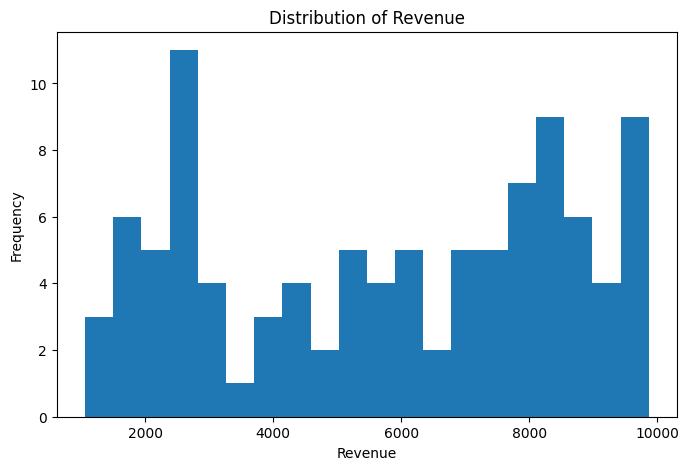

In [64]:


plt.figure(figsize=(8,5))

plt.hist(df["Revenue generated"], bins=20)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.show()

In [66]:
## 1. Supplier mana yang memiliki biaya terbesar?
supplier_cost = (
    df.groupby("Supplier name")["Costs"]
      .sum()
      .sort_values(ascending=False)
)

print(supplier_cost)

Supplier name
Supplier 1    15520.980745
Supplier 2    11330.599298
Supplier 5     9648.409132
Supplier 4     9392.587517
Supplier 3     7032.001523
Name: Costs, dtype: float64


In [67]:
#1. Shipping carrier mana yang memiliki rata-rata shipping cost tertinggi?

shipping_cost = (
    df.groupby("Shipping carriers")["Shipping costs"]
      .mean()
      .sort_values(ascending=False)
)

print(shipping_cost)

Shipping carriers
Carrier C    5.599292
Carrier A    5.554923
Carrier B    5.509247
Name: Shipping costs, dtype: float64


In [68]:
#2.  Transportation mode mana yang memiliki shipping time paling cepat?
shipping_time = (
    df.groupby("Transportation modes")["Shipping times"]
      .mean()
      .sort_values()
)

print(shipping_time)

Transportation modes
Road    4.724138
Air     5.115385
Rail    6.571429
Sea     7.117647
Name: Shipping times, dtype: float64


In [69]:
#1. Produk mana yang memiliki stock terbanyak?
stock_by_product = (
    df.groupby("Product type")["Stock levels"]
      .mean()
      .sort_values(ascending=False)
)

print(stock_by_product)

Product type
cosmetics    58.653846
haircare     48.352941
skincare     40.200000
Name: Stock levels, dtype: float64


In [70]:
#2. Apakah jumlah produk yang terjual berhubungan dengan stock tersedia?
correlation = df[
    ["Stock levels", "Number of products sold"]
].corr()

print(correlation)

                         Stock levels  Number of products sold
Stock levels                 1.000000                 0.022189
Number of products sold      0.022189                 1.000000


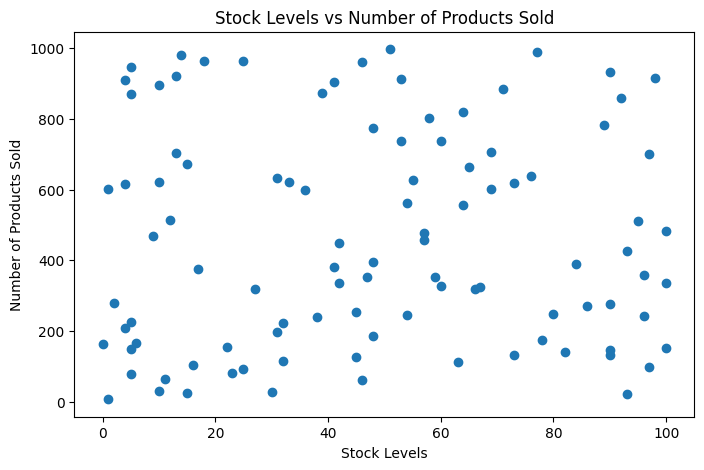

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Stock levels"],
    df["Number of products sold"]
)

plt.xlabel("Stock Levels")
plt.ylabel("Number of Products Sold")
plt.title("Stock Levels vs Number of Products Sold")

plt.show()

In [72]:
# 1. Berapa total manufactaring c0st dan shipping cost?

total_manufacturing_cost = df["Manufacturing costs"].sum()
total_shipping_cost = df["Shipping costs"].sum()

print(f"Total Manufacturing Cost: ${total_manufacturing_cost:,.2f}")
print(f"Total Shipping Cost: ${total_shipping_cost:,.2f}")

Total Manufacturing Cost: $4,726.67
Total Shipping Cost: $554.81


In [81]:
# 2. Produk mana yang memiliki penjualan terbesar?
product_inventory = (
    df.groupby("Product type")
      .agg(
          total_sold=("Number of products sold", "sum"),
          avg_stock=("Stock levels", "mean")
      )
      .sort_values("total_sold", ascending=False)
)

print(product_inventory)

              total_sold  avg_stock
Product type                       
skincare           20731  40.200000
haircare           13611  48.352941
cosmetics          11757  58.653846


In [85]:
product_analysis = (
    df.groupby("Product type")
      .agg(
          total_sold=("Number of products sold", "sum"),
          total_revenue=("Revenue generated", "sum"),
          avg_stock=("Stock levels", "mean")
      )
      .sort_values("total_sold", ascending=False)
)

print(product_analysis)

              total_sold  total_revenue  avg_stock
Product type                                      
skincare           20731  241628.162133  40.200000
haircare           13611  174455.390605  48.352941
cosmetics          11757  161521.265999  58.653846


# Business Insight

1. Perusahaan Menghasilkan revenue sebesar $577,604.82
2. Skincare menjadi kontributor revenue terbesar.
3. Supplier 1 membutuhkan biaya supply chain paling besar dengan biaya 15520.980745
4. Carrier C relatif lebih mahal
5. Road memiliki waktu pengiriman paling cepat
6. Cosmetics memiliki stock yang paling banyak/Tertinggi
7. Hampir tidak terdapat hubungan linear antara stock dan penjualan. r = 0,022
8. Skincare memiliki penjualan paling tinggi tetapi rata-rata stock paling rendah.
9. Cosmetics memiliki stock rata-rata paling tinggi, tetapi justru memiliki penjualan paling rendah.




**ID** Cosmetics memiliki jumlah penjualan tertinggi sekaligus menghasilkan revenue terbesar dibandingkan kategori produk lainnya. Hal ini menunjukkan bahwa Cosmetics merupakan kategori produk dengan performa terbaik, baik dari sisi volume penjualan maupun pendapatan. Cosmetics dapat menjadi prioritas dalam perencanaan inventory dan supply chain untuk memastikan ketersediaan stock yang cukup dan mengurangi risiko stockout.

**EN** Cosmetics has the highest sales volume and generates the highest revenue among all product categories, indicating that Cosmetics is the strongest-performing product category in terms of both sales volume and revenue.
Cosmetics should be prioritized in inventory planning and supply chain management to ensure sufficient stock availability and prevent potential stockouts.

**ID** Skincare memiliki penjualan dan revenue tertinggi tetapi rata-rata stock paling rendah. Sebaliknya, Cosmetics memiliki rata-rata stock paling tinggi meskipun memiliki penjualan paling rendah. Hal ini dapat mengindikasikan bahwa tingkat inventory belum sepenuhnya disesuaikan dengan demand produk.

**EN** Skincare has the highest sales volume and revenue but the lowest average stock level among the three product categories. In contrast, Cosmetics has the highest average stock level despite having the lowest sales volume. This may indicate that inventory levels are not fully aligned with product demand.






**ID** **Skincare merupakan produk dengan demand tertinggi, tetapi memiliki stock rata-rata paling rendah. Sebaliknya, Cosmetics memiliki demand paling rendah tetapi stock rata-rata paling tinggi. Kondisi ini menunjukkan bahwa persediaan belum sepenuhnya mengikuti pola permintaan.**

**EN** **Skincare has the highest demand but the lowest average stock level. In contrast, Cosmetics has the lowest demand but the highest average stock level. This indicates that inventory levels are not fully aligned with product demand.**

# Recommendation
**EN**The company should strengthen replenishment planning for high-demand products and optimize inventory levels for low-demand products to reduce the risk of stockouts and overstock.

**ID** Perusahaan perlu menambah persediaan untuk produk yang banyak diminati dan mengurangi persediaan untuk produk yang kurang diminati agar tidak terjadi kelebihan stok.